 # Project 7: Explanatory Data Analysis & Advanced Visualization (Baby Names Dataset)

## First Inspection: The most popular Names in 2018

1. __Load__ and __inspect__ the dataset "us_baby_names.csv". __Save__ the DataFrame in __df__.

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('/Users/anoushka/Desktop/Project_07_Materials/us_baby_names.csv')

In [4]:
df.columns

Index(['Year', 'Name', 'Gender', 'Count'], dtype='object')

2. Find the most popular __Baby Girl Names__ in __2018__. 

In [11]:
names_2018_F = df[(df['Year']==2018) & (df['Gender'] == 'F')]

In [12]:
names_2018_F.nlargest(10, 'Count')

,Year,Name,Gender,Count
1925013,2018,Emma,F,18688
1925014,2018,Olivia,F,17921
1925015,2018,Ava,F,14924
1925016,2018,Isabella,F,14464
1925017,2018,Sophia,F,13928
1925018,2018,Charlotte,F,12940
1925019,2018,Mia,F,12642
1925020,2018,Amelia,F,12301
1925021,2018,Harper,F,10582
1925022,2018,Evelyn,F,10376


3. Find the most popular __Baby Boy Names__ in __2018__.

In [13]:
names_2018_M = df[(df['Year']==2018) & (df['Gender'] == 'M')]

In [14]:
names_2018_M.nlargest(10, 'Count')

,Year,Name,Gender,Count
1943042,2018,Liam,M,19837
1943043,2018,Noah,M,18267
1943044,2018,William,M,14516
1943045,2018,James,M,13525
1943046,2018,Oliver,M,13389
1943047,2018,Benjamin,M,13381
1943048,2018,Elijah,M,12886
1943049,2018,Lucas,M,12585
1943050,2018,Mason,M,12435
1943051,2018,Logan,M,12352


4. __Create__ the function __most_pop(year, gender, n)__ that returns the __n__ most popular __M/F__ Names in the __year XYZ__.

In [17]:
def most_pop(year, gender, n):
    return df[(df['Year']==year) & (df['Gender'] == gender)].nlargest(n,'Count')

In [20]:
most_pop(1880, 'F', 10)

,Year,Name,Gender,Count
0,1880,Mary,F,7065
1,1880,Anna,F,2604
2,1880,Emma,F,2003
3,1880,Elizabeth,F,1939
4,1880,Minnie,F,1746
5,1880,Margaret,F,1578
6,1880,Ida,F,1472
7,1880,Alice,F,1414
8,1880,Bertha,F,1320
9,1880,Sarah,F,1288


In [21]:
most_pop(1880, 'M', 10)

,Year,Name,Gender,Count
942,1880,John,M,9655
943,1880,William,M,9532
944,1880,James,M,5927
945,1880,Charles,M,5348
946,1880,George,M,5126
947,1880,Frank,M,3242
948,1880,Joseph,M,2632
949,1880,Thomas,M,2534
950,1880,Henry,M,2444
951,1880,Robert,M,2415


## Evergreen Names (1880 - 2018)

5. Find those __Evergreen Boy Names__ that are in __1880 and 2018__ among the most popular Boy Names (__Top 20__).

In [34]:
most_pop_1880_M = most_pop(1880, 'M', 20)
most_pop_2018_M = most_pop(2018, 'M', 20)

In [36]:
joined_M = pd.merge(
    most_pop_1880_M, 
    most_pop_2018_M, 
    how = 'inner',
    on = 'Name', 
    suffixes=('_1880', '_2018')
)
joined_M

,Year_1880,Name,Gender_1880,Count_1880,Year_2018,Gender_2018,Count_2018
0,1880,William,M,9532,2018,M,14516
1,1880,James,M,5927,2018,M,13525
2,1880,Henry,M,2444,2018,M,10649


6. Find those __Evergreen Girl Names__ that are in __1880 and 2018__ among the most popular Girl Names (__Top 20__).

In [32]:
most_pop_1880_F = most_pop(1880, 'F', 20)
most_pop_2018_F = most_pop(2018, 'F', 20)

In [33]:
joined_F = pd.merge(
    most_pop_1880_F, 
    most_pop_2018_F, 
    how = 'inner',
    on = 'Name', 
    suffixes=('_1880', '_2018')
)
joined_F

,Year_1880,Name,Gender_1880,Count_1880,Year_2018,Gender_2018,Count_2018
0,1880,Emma,F,2003,2018,F,18688
1,1880,Elizabeth,F,1939,2018,F,8513
2,1880,Ella,F,1156,2018,F,8055


## Advanced Data Aggregation

7. Create the following __aggregated DataFrame agg__ (you can see the first and last 5 rows):

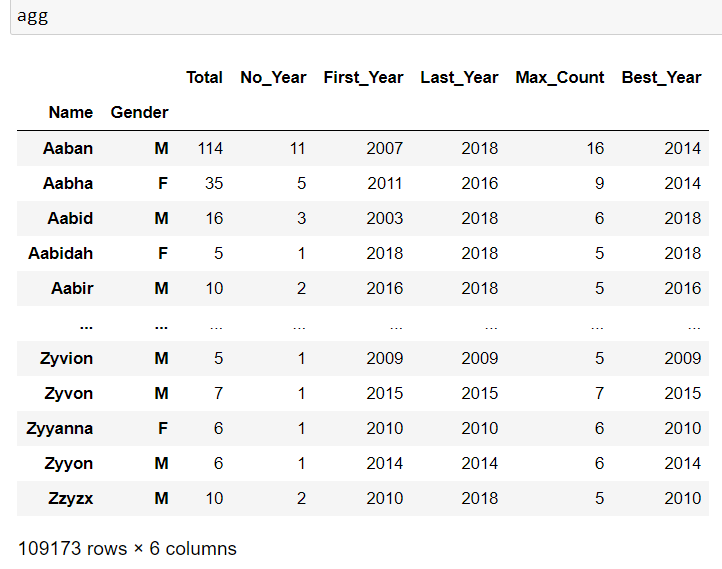

__How to interpret agg (and the first observation Aaban, M):__<br>
- There are in total 114 Male Babies with the name Aaban (Total)<br>
- The combination/entry (Aaban, M) can be found in 11 different years (No_Year)<br>
- The combination/entry (Aaban, M) appeared in the year 2007 for the first time (First_Year)<br>
- The last appearance was in the year 2018 (Last_Year)<br>
- In the most popular year, (Aaban, M) appeared 16 times (Max_Count)
- The most popular year for (Aaban, M) (Best_Year)

In [37]:
df.groupby(["Name", "Gender"]).Count.sum().reset_index(level = -1)

,Gender,Count
Name,,
Aaban,M,114
Aabha,F,35
Aabid,M,16
Aabidah,F,5
Aabir,M,10
...,...,...
Zyvion,M,5
Zyvon,M,7
Zyyanna,F,6


In [38]:
agg = df.groupby(["Name", "Gender"]).agg(Total = ("Count", "sum"), No_Year = ("Count", "count"), 
                                         First_Year = ("Year", "min"), Last_Year = ("Year", "max"),
                                         Max_Count = ("Count", "max"))

In [39]:
agg

,,Total,No_Year,First_Year,Last_Year,Max_Count
Name,Gender,,,,,
Aaban,M,114,11,2007,2018,16
Aabha,F,35,5,2011,2016,9
Aabid,M,16,3,2003,2018,6
Aabidah,F,5,1,2018,2018,5
Aabir,M,10,2,2016,2018,5
...,...,...,...,...,...,...
Zyvion,M,5,1,2009,2009,5
Zyvon,M,7,1,2015,2015,7
Zyyanna,F,6,1,2010,2010,6


8. __Reset__ the Index and create a RangeIndex.

In [40]:
agg.reset_index(inplace = True)

In [41]:
agg['rank'] = range(1, len(agg) + 1)

In [42]:
agg.set_index('rank', inplace=True)

In [43]:
agg

,Name,Gender,Total,No_Year,First_Year,Last_Year,Max_Count
rank,,,,,,,
1,Aaban,M,114,11,2007,2018,16
2,Aabha,F,35,5,2011,2016,9
3,Aabid,M,16,3,2003,2018,6
4,Aabidah,F,5,1,2018,2018,5
5,Aabir,M,10,2,2016,2018,5
...,...,...,...,...,...,...,...
109169,Zyvion,M,5,1,2009,2009,5
109170,Zyvon,M,7,1,2015,2015,7
109171,Zyyanna,F,6,1,2010,2010,6


9. __Filter__ agg for the combination (Mary, F)

In [44]:
agg[(agg['Name']=='Mary')& (agg['Gender']=='F')]

,Name,Gender,Total,No_Year,First_Year,Last_Year,Max_Count
rank,,,,,,,
68680,Mary,F,4125675,139,1880,2018,73985


## Most Popular Names of all Times

10. __Find__ the __10 most popular__ Male and Female Names of all Times (most popular in terms of total count). See Screenshot with final result below.

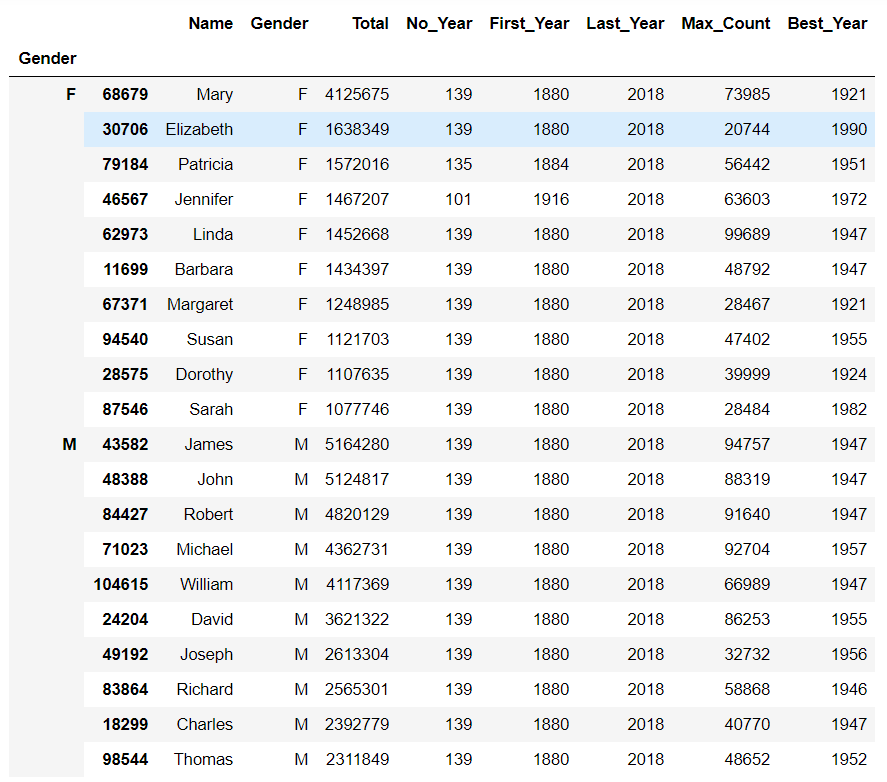

In [50]:
all_times = agg.groupby("Gender").apply(lambda x: x.nlargest(10, "Total"), include_groups=False).reset_index(drop = False)
all_times

,Gender,rank,Name,Total,No_Year,First_Year,Last_Year,Max_Count
0,F,68680,Mary,4125675,139,1880,2018,73985
1,F,30707,Elizabeth,1638349,139,1880,2018,20744
2,F,79185,Patricia,1572016,135,1884,2018,56442
3,F,46568,Jennifer,1467207,101,1916,2018,63603
4,F,62974,Linda,1452668,139,1880,2018,99689
5,F,11700,Barbara,1434397,139,1880,2018,48792
6,F,67372,Margaret,1248985,139,1880,2018,28467
7,F,94541,Susan,1121703,139,1880,2018,47402
8,F,28576,Dorothy,1107635,139,1880,2018,39999
9,F,87547,Sarah,1077746,139,1880,2018,28484


In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

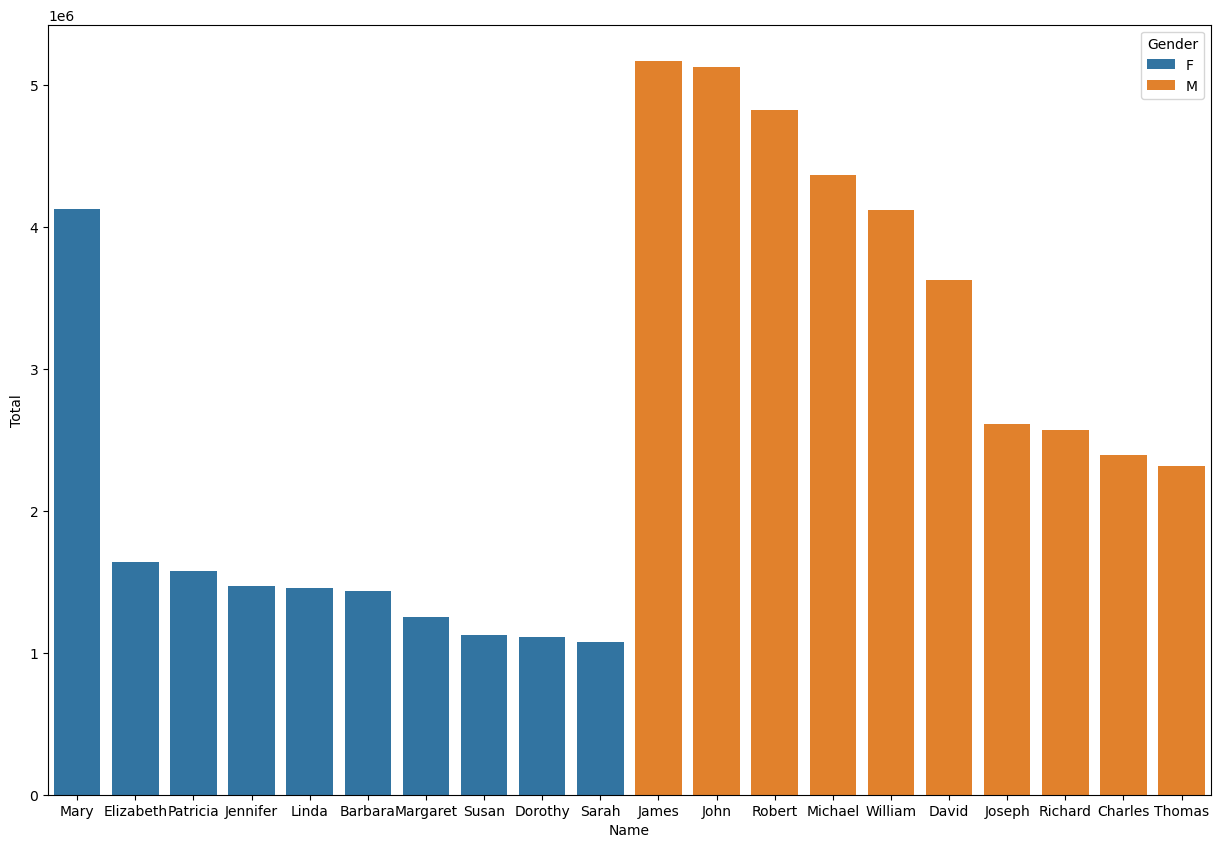

In [54]:
plt.figure(figsize = (15, 10))
sns.barplot(x = "Name", y = "Total", data = all_times, hue = "Gender")
plt.show()

## General Trends over time (1880 - 2018)

11. __Count__ the total number of __registered Babies per Year__ and visualize.

In [56]:
babies_per_year = df.groupby("Year").Count.sum()

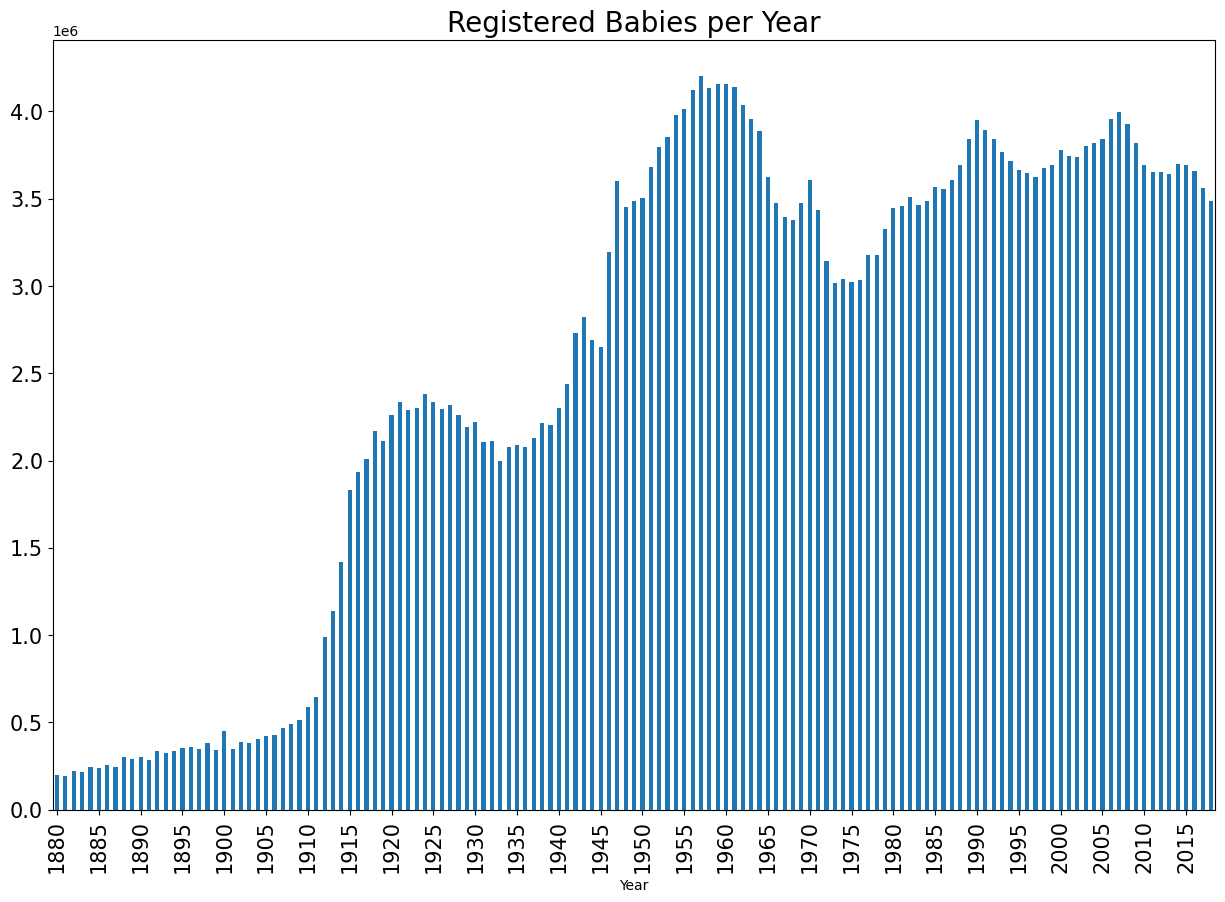

In [57]:
babies_per_year.plot(kind = "bar", y= "Count", figsize = (15, 10), fontsize = 15)
plt.xticks(ticks = (range(0, len(babies_per_year), 5)), labels =  range(1880, 2019, 5))
plt.title("Registered Babies per Year", fontsize = 20)
plt.show()

12. __Count__ the total number of __Unique Names per Year__ and visualize. 

In [58]:
diff_names = df.groupby("Year").Name.count()
diff_names

Year
1880     2000
1881     1935
1882     2127
1883     2084
1884     2297
        ...  
2014    33243
2015    33121
2016    33010
2017    32590
2018    32033
Name: Name, Length: 139, dtype: int64

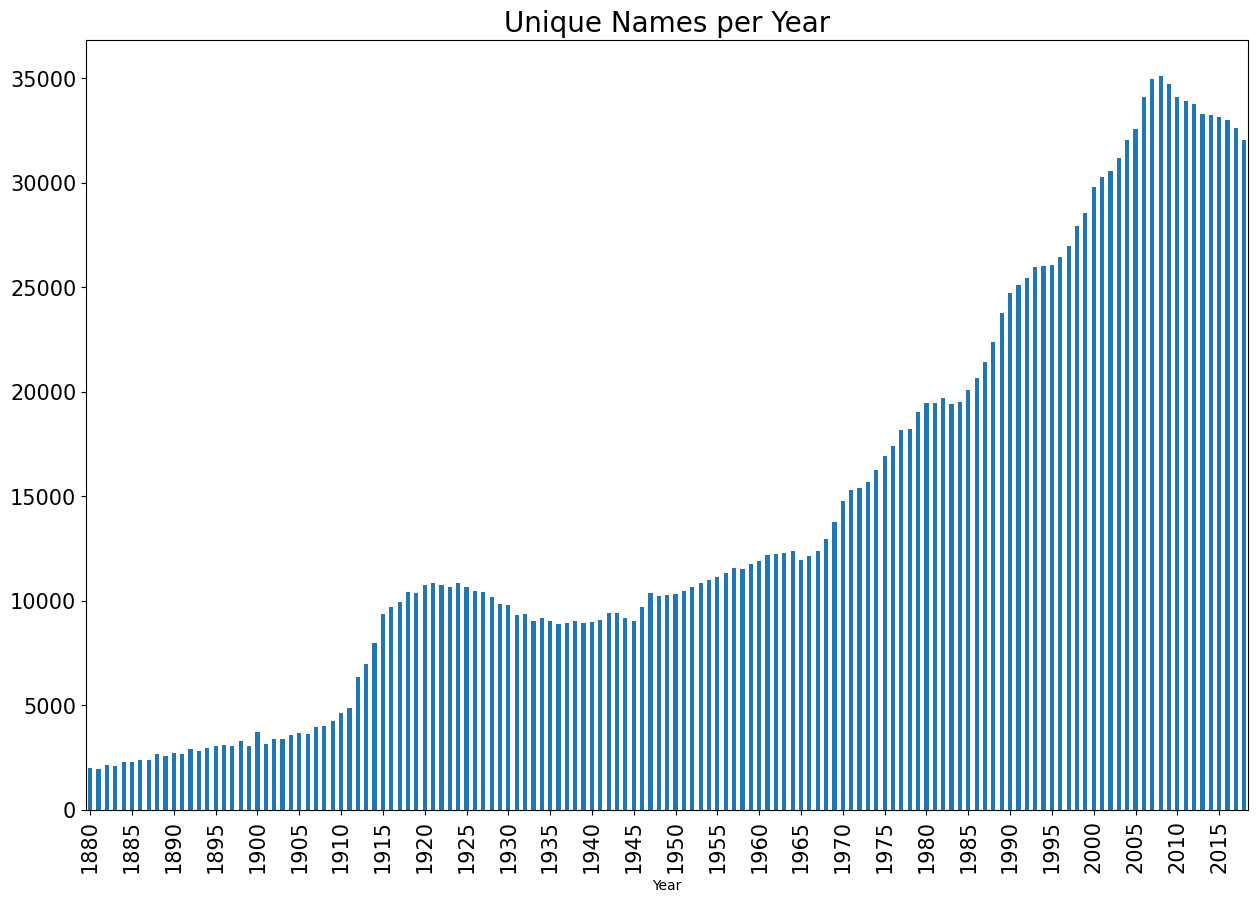

In [59]:
diff_names.plot(kind = "bar", figsize = (15, 10), fontsize = 15)
plt.xticks(ticks = (range(0, len(diff_names), 5)), labels =  range(1880, 2019, 5))
plt.title("Unique Names per Year", fontsize = 20)
plt.show()

## Creating the Features "Popularity" and "Rank"

13. __Add__ the column __"Popularity"__ to df: <br> 

- Popularity in __babies per million__ (example: assume 2,000,000 registered Girl Names in 1950, thereof 100,000 Maries -> Popularity Score in 1950 for (Mary, F) is 100,000 / 2,000,000 * 1,000,000 = 50,000 per million.)  

In [60]:
df.groupby(["Year", "Gender"]).Count.transform("sum")

0            90994
1            90994
2            90994
3            90994
4            90994
            ...   
1957041    1800392
1957042    1800392
1957043    1800392
1957044    1800392
1957045    1800392
Name: Count, Length: 1957046, dtype: int64

In [61]:
df.Count.div(df.groupby(["Year", "Gender"]).Count.transform("sum"))*1000000

0          77642.481922
1          28617.271468
2          22012.440381
3          21309.097303
4          19188.078335
               ...     
1957041        2.777173
1957042        2.777173
1957043        2.777173
1957044        2.777173
1957045        2.777173
Name: Count, Length: 1957046, dtype: float64

In [62]:
df["Popularity"] = df.Count.div(df.groupby(["Year", "Gender"]).Count.transform("sum"))*1000000

In [63]:
df

,Year,Name,Gender,Count,Popularity
0,1880,Mary,F,7065,77642.481922
1,1880,Anna,F,2604,28617.271468
2,1880,Emma,F,2003,22012.440381
3,1880,Elizabeth,F,1939,21309.097303
4,1880,Minnie,F,1746,19188.078335
...,...,...,...,...,...
1957041,2018,Zylas,M,5,2.777173
1957042,2018,Zyran,M,5,2.777173
1957043,2018,Zyrie,M,5,2.777173
1957044,2018,Zyron,M,5,2.777173


# Why does a Name´s Popularity suddenly change? (Part 1)

17. __Add__ the additional columns __"Pop_lag1"__ (Popularity one year ago) and __"Pop_diff"__ (change in popularity from previous year to this year) to df.  

In [72]:
df.loc[(df.Name == "Mary") & (df.Gender == "F"), "Popularity"].shift()

0                   NaN
2000       77642.481922
3935       75244.962100
6062       75551.475702
8146       71332.543915
               ...     
1793168     1513.715369
1826414     1476.702107
1859539     1477.713818
1892548     1419.988088
1925138     1397.211859
Name: Popularity, Length: 139, dtype: float64

In [73]:
df["Pop_lag1"] = df.groupby(["Name", "Gender"]).Popularity.shift()

In [74]:
df.loc[(df.Year > 1880) & (df.Pop_lag1.isna()), "Pop_lag1"] = 0

In [75]:
df["Pop_diff"] = df.Popularity - df.Pop_lag1

18. __Create__ df2 starting with the __year 1900__ (from 1900 till today).

In [76]:
df2 = df[df.Year >= 1900].copy()

19. __Filter__ df2 and find the __20 largest values__ in "Pop_diff" (get complete rows).

In [77]:
df2.nlargest(20, "Pop_diff")

,Year,Name,Gender,Count,Popularity,Pop_lag1,Pop_diff
431066,1947,Linda,F,99689,56236.224976,33546.795584,22689.429392
321479,1935,Shirley,F,42358,40398.317993,21874.356531,18523.961462
922468,1983,Ashley,F,33293,19930.187772,8774.639361,11155.548411
711426,1971,Jennifer,F,56783,34133.547814,26403.416193,7730.131621
726721,1972,Jennifer,F,63603,41813.296659,34133.547814,7679.748845
312301,1934,Shirley,F,22840,21874.356531,14203.488412,7670.868118
645417,1966,Michelle,F,27151,16047.477506,9186.178467,6861.299039
751941,1973,Jason,M,46683,29939.989187,23080.621302,6859.367885
844807,1979,Amanda,F,31928,19889.848316,13393.836368,6496.011948
696647,1970,Jennifer,F,46157,26403.416193,19977.960342,6425.455851


In [78]:
df2.nsmallest(20, "Pop_diff")

,Year,Name,Gender,Count,Popularity,Pop_lag1,Pop_diff
339412,1937,Shirley,F,26816,25204.262994,33797.507168,-8593.244174
330516,1936,Shirley,F,35161,33797.507168,40398.317993,-6600.810824
461947,1950,Linda,F,80431,46951.516726,53199.224714,-6247.707988
472250,1951,Linda,F,73978,41079.216509,46951.516726,-5872.300217
961380,1985,Jennifer,F,42651,24789.454412,30032.147389,-5242.692976
482712,1952,Linda,F,67082,36174.484375,41079.216509,-4904.732133
696648,1970,Lisa,F,38963,22288.196917,26692.409241,-4404.212323
437173,1947,Richard,M,58521,31989.596453,36252.451758,-4262.855305
537623,1957,Deborah,F,40071,19601.225058,23826.731344,-4225.506286
504196,1954,Linda,F,55381,28520.371510,32572.095261,-4051.723751


## Persistant vs. Spike-Fade Names

In [81]:
agg["Spike_Score"] = agg.Max_Count.div(agg.Total).mul(100)

In [82]:
agg.sort_values(by = "Spike_Score", ascending = True).head(20)

,Name,Gender,Total,No_Year,First_Year,Last_Year,Max_Count,Spike_Score
rank,,,,,,,,
49193,Joseph,M,2613304,139,1880,2018,32732,1.252514
30707,Elizabeth,F,1638349,139,1880,2018,20744,1.266153
85134,Rosa,F,174125,139,1880,2018,2230,1.280689
69243,Maurice,M,134504,139,1880,2018,1743,1.295872
25420,Delia,F,36276,139,1880,2018,491,1.353512
21173,Cornelius,M,35764,139,1880,2018,485,1.356112
28010,Domingo,M,13797,121,1882,2018,190,1.377111
68441,Marshall,M,91352,139,1880,2018,1270,1.390227
97754,Teodoro,M,3079,111,1884,2018,43,1.396557


In [83]:
pers = agg.sort_values(by = "Spike_Score", ascending = True).head(20)

In [86]:
spike = agg[(agg.Total > 1000) & (agg.No_Year > 10)].sort_values(by = "Spike_Score",
                                                                 ascending = False).head(20)
spike

,Name,Gender,Total,No_Year,First_Year,Last_Year,Max_Count,Spike_Score
rank,,,,,,,,
57028,Kizzy,F,2325,30,1977,2016,1116,48.000000
77283,Oaklyn,F,1381,11,2006,2018,627,45.401883
25999,Deneen,F,3603,52,1947,2007,1604,44.518457
72224,Moesha,F,1067,14,1996,2014,426,39.925023
67329,Mareli,F,1038,22,1995,2018,411,39.595376
67338,Marely,F,2606,29,1989,2018,1004,38.526477
51915,Kanye,M,1334,17,2002,2018,509,38.155922
50989,Kairo,M,1632,24,1995,2018,605,37.071078
97721,Tennille,F,2172,32,1975,2012,769,35.405157


## Most Popular Unisex Names

22. __Find__ the most popular __Unisex Names__ of all times. (Unisex names are names given to Boys and Girls).  

In [89]:
df.groupby(["Name", "Gender"]).Count.sum().unstack()

Gender,F,M
Name,,
Aaban,NaN,114.0
Aabha,35.0,NaN
Aabid,NaN,16.0
Aabidah,5.0,NaN
Aabir,NaN,10.0
...,...,...
Zyvion,NaN,5.0
Zyvon,NaN,7.0
Zyyanna,6.0,NaN


In [90]:
unisex = df.groupby(["Name", "Gender"]).Count.sum().unstack()
unisex

Gender,F,M
Name,,
Aaban,NaN,114.0
Aabha,35.0,NaN
Aabid,NaN,16.0
Aabidah,5.0,NaN
Aabir,NaN,10.0
...,...,...
Zyvion,NaN,5.0
Zyvon,NaN,7.0
Zyyanna,6.0,NaN


In [91]:
unisex.dropna(inplace = True)

In [92]:
unisex.min(axis = 1).sort_values(ascending = False)

Name
Willie    146156.0
Jordan    131004.0
Leslie    112726.0
Taylor    110390.0
Jessie    110212.0
            ...   
Hany           5.0
Hao            5.0
Haram          5.0
Harjap         5.0
Aaden          5.0
Length: 10773, dtype: float64

In [93]:
unisex_names = unisex.min(axis = 1).sort_values(ascending = False).index
unisex_names

Index(['Willie', 'Jordan', 'Leslie', 'Taylor', 'Jessie', 'Terry', 'Angel',
       'Riley', 'Jamie', 'Kelly',
       ...
       'Hanalei', 'Handy', 'Haniel', 'Hans', 'Hansel', 'Hany', 'Hao', 'Haram',
       'Harjap', 'Aaden'],
      dtype='object', name='Name', length=10773)

In [94]:
unisex.loc[unisex_names].head(20)

Gender,F,M
Name,,
Willie,146156.0,448946.0
Jordan,131004.0,374513.0
Leslie,267081.0,112726.0
Taylor,320446.0,110390.0
Jessie,167462.0,110212.0
Terry,96895.0,422916.0
Angel,95710.0,231800.0
Riley,106901.0,94278.0
Jamie,268102.0,85631.0


In [95]:
unisex = unisex[unisex.min(axis = 1) > 10000]
unisex

Gender,F,M
Name,,
Addison,121435.0,12895.0
Adrian,15258.0,237044.0
Alexis,338333.0,63604.0
Amari,14415.0,17932.0
Angel,95710.0,231800.0
...,...,...
Tommie,17415.0,34210.0
Tracy,250853.0,61223.0
Tyler,16585.0,587571.0


In [96]:
abs(unisex.F.div(unisex.M).sub(1)).sort_values()

Name
Elisha        0.012284
Quinn         0.012504
Kerry         0.022096
Blair         0.027191
Kris          0.039203
               ...    
Stacey        9.603498
Courtney     10.344524
Jean         18.069971
Ashley       53.003064
Mary        271.052423
Length: 116, dtype: float64

In [97]:
unisex_names2 = abs(unisex.F.div(unisex.M).sub(1)).sort_values().index
unisex_names2

Index(['Elisha', 'Quinn', 'Kerry', 'Blair', 'Kris', 'Robbie', 'Justice',
       'Riley', 'Emerson', 'Jackie',
       ...
       'Sandy', 'Stacy', 'Carmen', 'Shelby', 'Addison', 'Stacey', 'Courtney',
       'Jean', 'Ashley', 'Mary'],
      dtype='object', name='Name', length=116)

In [98]:
unisex.loc[unisex_names2].head(20)

Gender,F,M
Name,,
Elisha,13762.0,13595.0
Quinn,31670.0,32071.0
Kerry,48549.0,49646.0
Blair,14922.0,14527.0
Kris,13504.0,14055.0
Robbie,22290.0,20926.0
Justice,16354.0,17580.0
Riley,106901.0,94278.0
Emerson,20904.0,24472.0
